# 1. Data and libraries load

In [30]:
import kagglehub

dataset_path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud", 
    
    output_dir="./.venv/data"
)

print(f"Files saved to: {dataset_path}")

Files saved to: ./.venv/data


In [31]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [32]:
df_raw = pd.read_csv(".venv/data/creditcard.csv")
df_raw.head(1)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0


# 2. Exploratory Data Analysis (EDA)

## 2.1 Decribing and counting values

In [33]:
df_raw.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


Look that almost every column in the dataset is scaled, with the solo exception of two columns, `Time` and `Amount`

In [34]:
print("No null values found!") if np.average(df_raw.isnull().sum()) == 0 else print("Ops, null values found")

No null values found!


In [35]:
df_raw.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')

In [36]:
pct = df_raw['Class'].value_counts()/len(df_raw) * 100

for i,val in enumerate(pct):
    print(f"{round(val,5)}% of the data is from class {i}")

99.82725% of the data is from class 0
0.17275% of the data is from class 1


Text(0.5, 1.0, 'Class Distributions \n (0: No Fraud | 1: Fraud)')

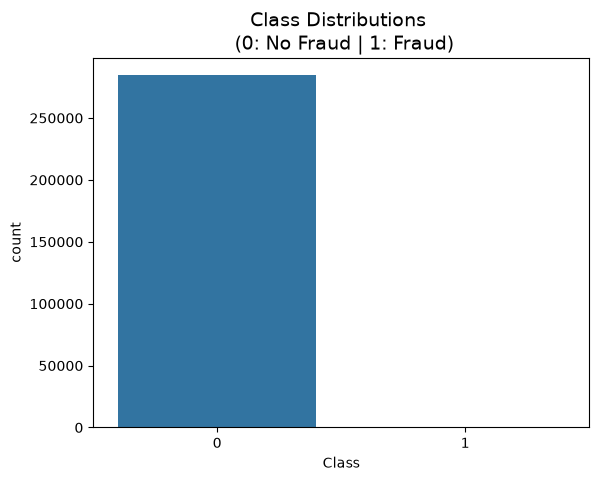

In [37]:
colors = ["#0101DF", "#DF0101"]

sns.countplot(x='Class', data=df_raw, hue_norm=colors)
plt.title('Class Distributions \n (0: No Fraud | 1: Fraud)', fontsize=14)

## 2.2 Normalizing the `Amount` and `Time`

In [38]:
from sklearn.preprocessing import StandardScaler, RobustScaler

The difference between `StandartScaler` and `RobustScaler` is in the mathematical formula used in the data to transform values:

* `StandartScaler` : $x' = \frac{x-\mu}{\sigma}$

* `RobustScaler` : $x'= \frac{x-Q2}{Q3-Q1} = \frac{x-Q2}{IQR}$

In [39]:
std_scaler = StandardScaler()
rob_scaler = RobustScaler()

In [40]:
df = df_raw.copy()
# df['robust_scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
# df['robust_scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df['standart_scaled_amount'] = std_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['standart_scaled_time'] = std_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [41]:
# Ordering columns
l = ['standart_scaled_amount','standart_scaled_time']
new_order = l + [col for col in df.columns if col not in l] 

df = df[new_order]

In [42]:
# robust_scaled_amount = df['robust_scaled_amount']
# robust_scaled_time = df['robust_scaled_time']

standart_scaled_amount = df['standart_scaled_amount']
standart_scaled_time = df['standart_scaled_time']

df.head(2)

,standart_scaled_amount,standart_scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
0,0.244964,-1.996583,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0
1,-0.342475,-1.996583,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0


In [43]:
df_fraud = df[df['Class']==1]

print(f"There is {len(df_fraud)} fraud transactions")

df_underSample = df[df['Class'] != 1].sample(frac=1)[:492]
print(f"There are {len(df_underSample)} non fraud transactions in the Under Sample, here is the proof: \nSum of the variable Class: {df_underSample['Class'].sum()}")

new_df = pd.concat([df_fraud,df_underSample]).sample(frac=1, random_state=1) # Concat the under sample and shuffle the data
new_df.head(2)

There is 492 fraud transactions
There are 492 non fraud transactions in the Under Sample, here is the proof: 
Sum of the variable Class: 0


,standart_scaled_amount,standart_scaled_time,V1,V2,V3,V4,V5,V6,V7,V8,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Class
115753,1.979574,-0.438297,0.160209,-2.388192,-0.720302,1.415090,0.690418,4.744632,-0.740510,1.009697,...,0.726874,-0.264402,-1.548064,-0.401924,0.976521,0.156073,-0.136158,-0.038644,0.133134,0
107637,2.944512,-0.511241,-2.271755,-0.457655,-2.589055,2.230778,-4.278983,0.388610,0.102485,0.813128,...,2.285758,1.096342,0.658399,1.711676,0.333540,0.538591,-0.193529,0.258194,0.247269,1


## 2.3 Correlation between balanced and imbalanced data

KeyboardInterrupt: 

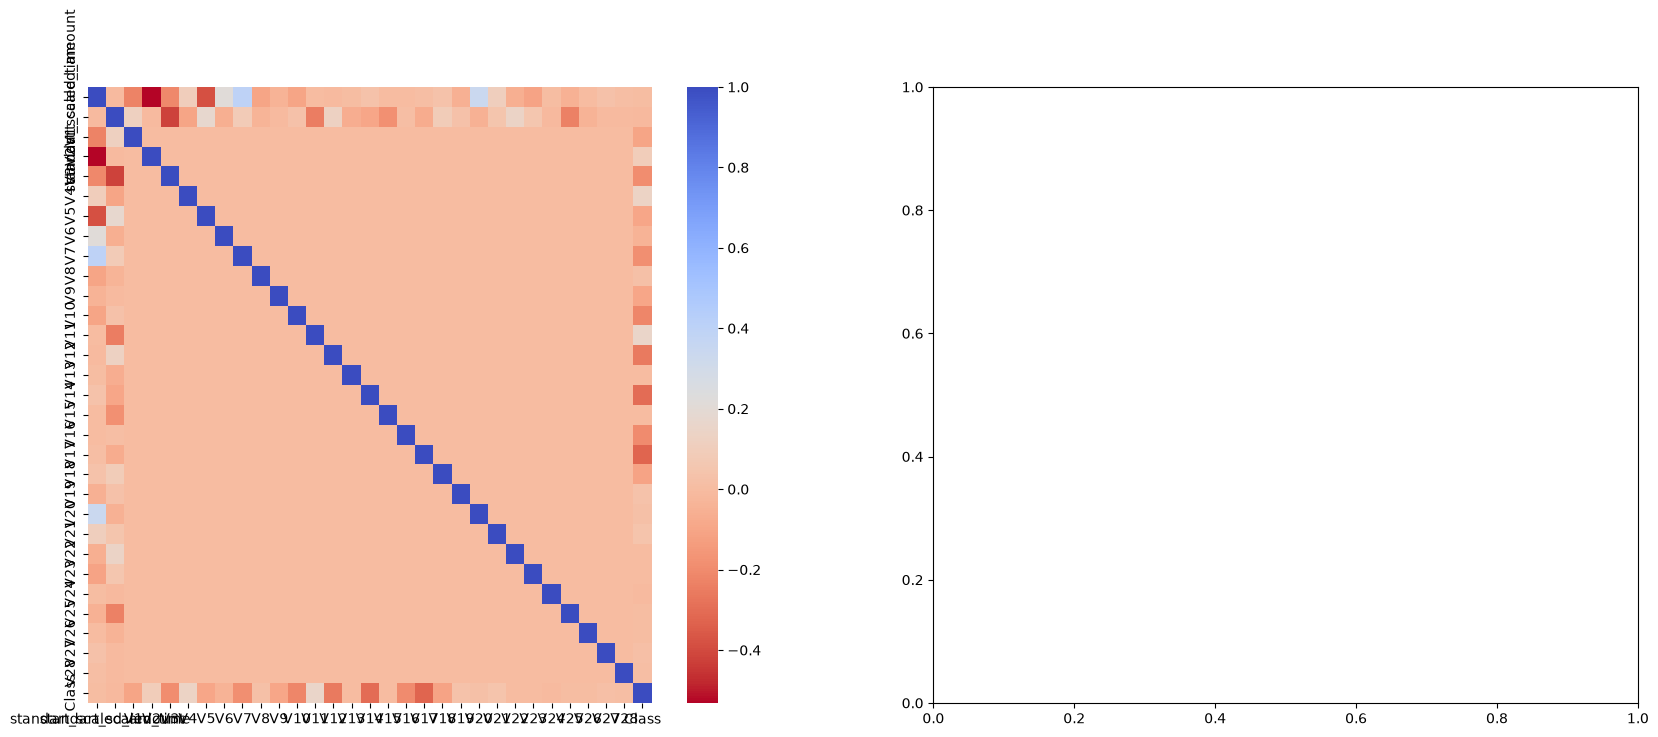

In [44]:
fig, axs = plt.subplots(1, 2, figsize=(20, 8))

# --- Primeiro Gráfico: Dataset Desbalanceado ---
sns.heatmap(
    df.corr(numeric_only=True), 
    cmap='coolwarm_r', 
    annot=False,    
    annot_kws={
        'size': 5,
        'color': 'black'
    },
    xticklabels=True, 
    yticklabels=True,
    ax=axs[0]
)

# Correção na rotação dos eixos e título do objeto Axes
axs[0].set_xticklabels(axs[0].get_xticklabels(), rotation=45, ha='right')
axs[0].set_yticklabels(axs[0].get_yticklabels(), rotation=0)
axs[0].set_title("Correlation Matrix with imbalanced dataset")


# --- Segundo Gráfico: Dataset Balanceado ---
sns.heatmap(
   new_df.corr(numeric_only=True), 
    cmap='coolwarm_r', 
    annot=False,    
    annot_kws={
        'size': 5,
        'color': 'black'
    },
    xticklabels=True, 
    yticklabels=True,
    ax=axs[1]
)

# Correção na rotação dos eixos e título do objeto Axes
axs[1].set_xticklabels(axs[1].get_xticklabels(), rotation=45, ha='right')
axs[1].set_yticklabels(axs[1].get_yticklabels(), rotation=0)
axs[1].set_title("Correlation Matrix with balanced dataset")


fig.tight_layout()
plt.show()

## 2.4 Plotting the most valuable correlations

In [ ]:
corr_Class = new_df.corr()['Class']
corr_Class.drop('Class',inplace=True)

negative_corr = corr_Class[corr_Class < 0].sort_values()
positive_corr = corr_Class[corr_Class > 0].sort_values()

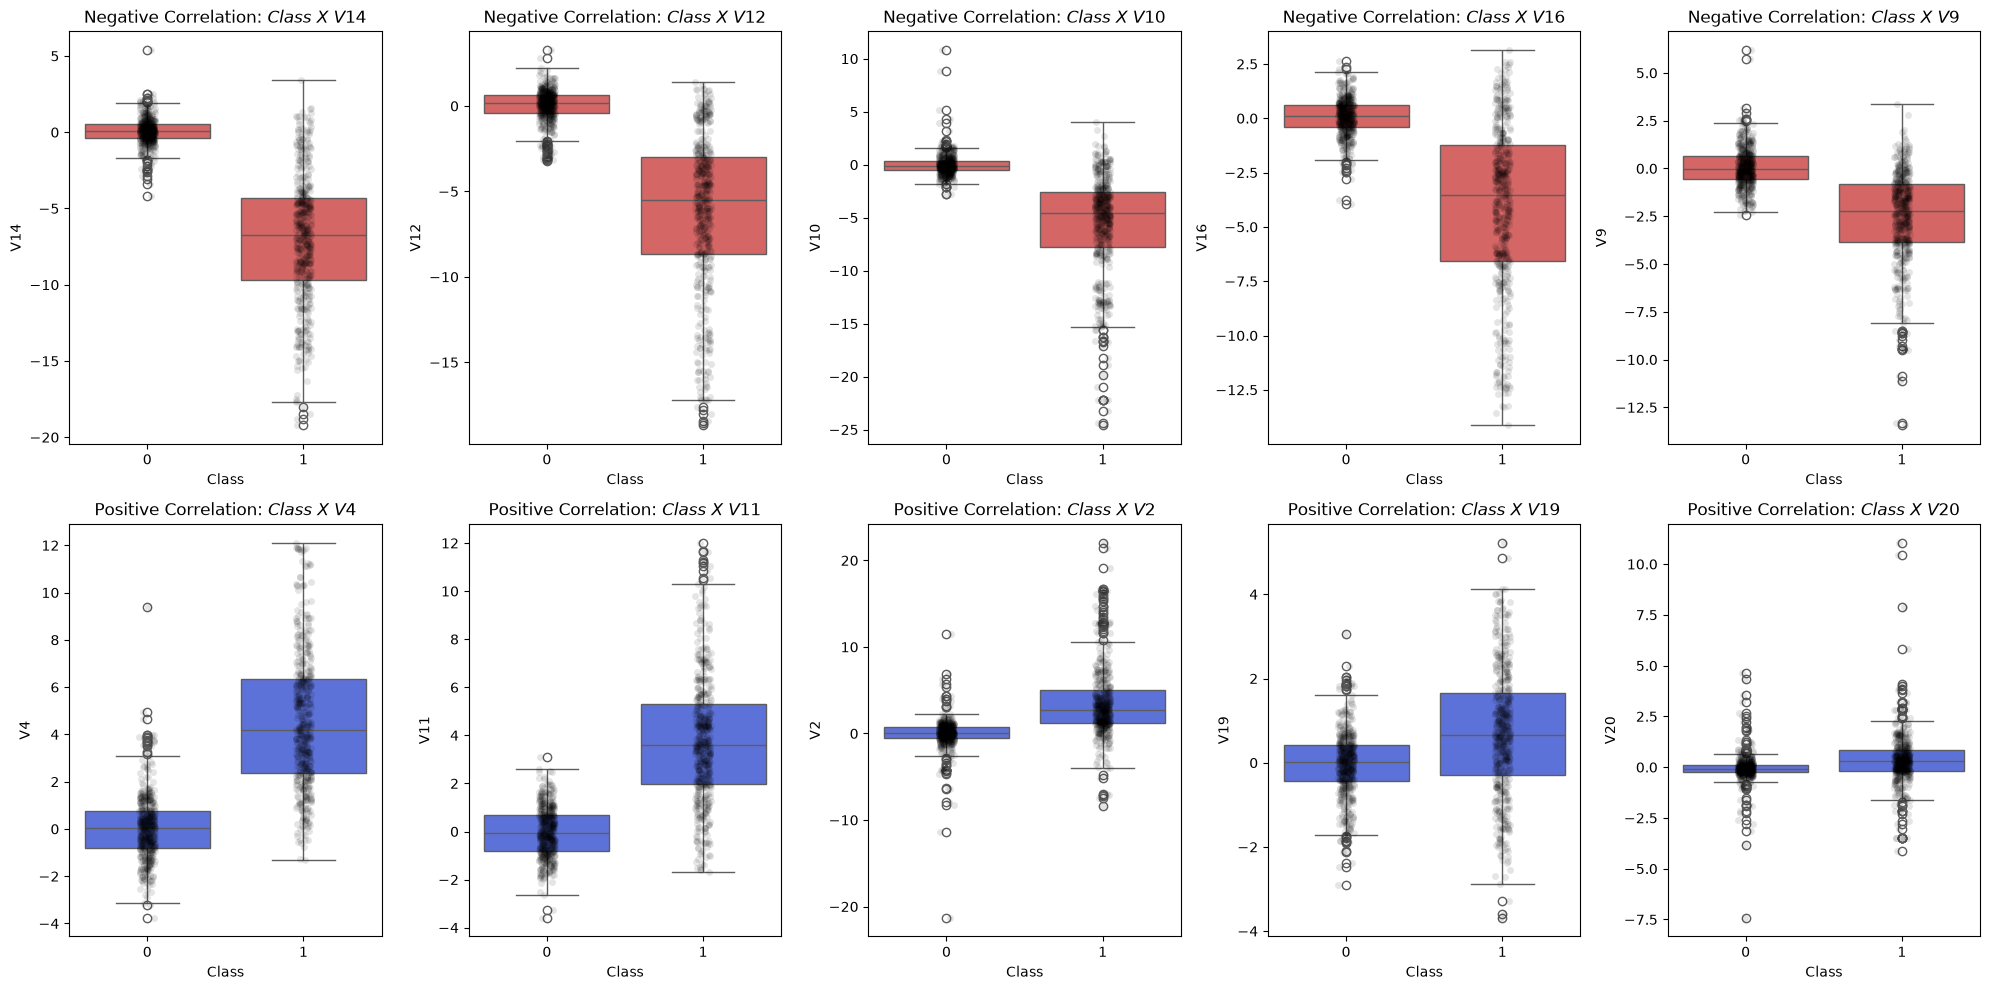

In [ ]:
fig, axs = plt.subplots(2, 5, figsize=(20, 10))

main_neg_vars = negative_corr.head(5).index

main_pos_vars = positive_corr.tail(5)[::-1].index 

for i, var in enumerate(main_neg_vars):
    sns.boxplot(data=new_df, x="Class", y=var, ax=axs[0, i],color='#e65454')
    sns.stripplot(data=new_df, x="Class", y=var, ax=axs[0,i],alpha=0.1,jitter=0.05,color="black")
    axs[0, i].set_title(fr"Negative Correlation: $Class\ X\ {var}$")

for i, var in enumerate(main_pos_vars):
    sns.boxplot(data=new_df, x="Class", y=var, ax=axs[1, i],color='#4965EC')
    sns.stripplot(data=new_df, x="Class", y=var, ax=axs[1,i],alpha=0.1,jitter=0.05,color="black")
    axs[1, i].set_title(fr"Positive Correlation: $Class\ X\ {var}$")

plt.tight_layout()
plt.show()

## 2.5 Distribution os those variables

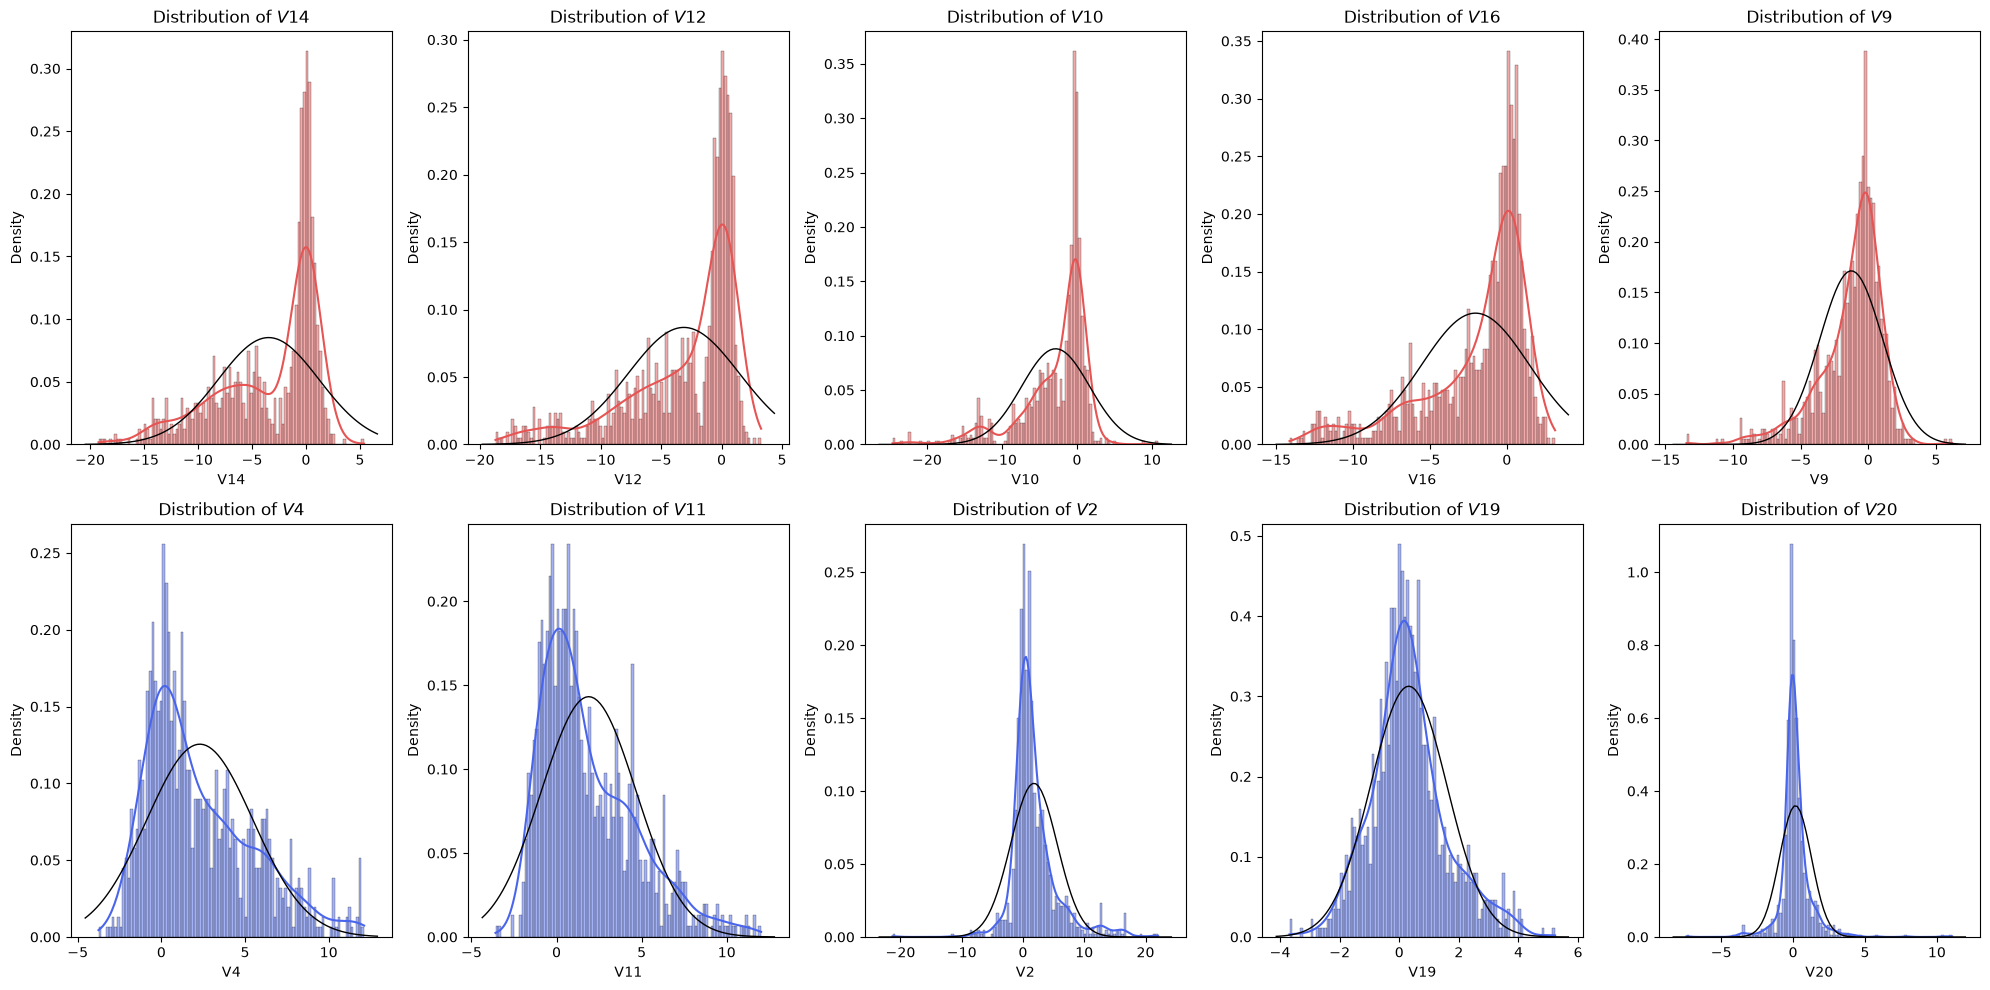

In [ ]:
from scipy.stats import norm

fig, axs = plt.subplots(2, 5, figsize=(20, 10))

N_bins = 100

for i, var in enumerate(main_neg_vars):
    data = new_df[var]

    sns.histplot(
        data=data,
        ax=axs[0, i],
        bins=N_bins,
        kde=True,
        stat='density',
        color='#e65454'
    )

    mu, std = norm.fit(data)
    xmin, xmax = axs[0, i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    axs[0, i].plot(x, p, 'k', linewidth=1)
    axs[0, i].set_title(fr"Distribution of ${var}$")


for i, var in enumerate(main_pos_vars):
    data = new_df[var]

    sns.histplot(
        data=data,
        ax=axs[1, i],
        bins=N_bins,
        kde=True,
        stat='density',
        color='#4965EC'
    )

    mu, std = norm.fit(data)
    xmin, xmax = axs[1, i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    axs[1, i].plot(x, p, 'k', linewidth=1)
    axs[1, i].set_title(fr"Distribution of ${var}$")


plt.tight_layout()
plt.show()

## 2.6 Seeing how well the variable can define the class of the observation

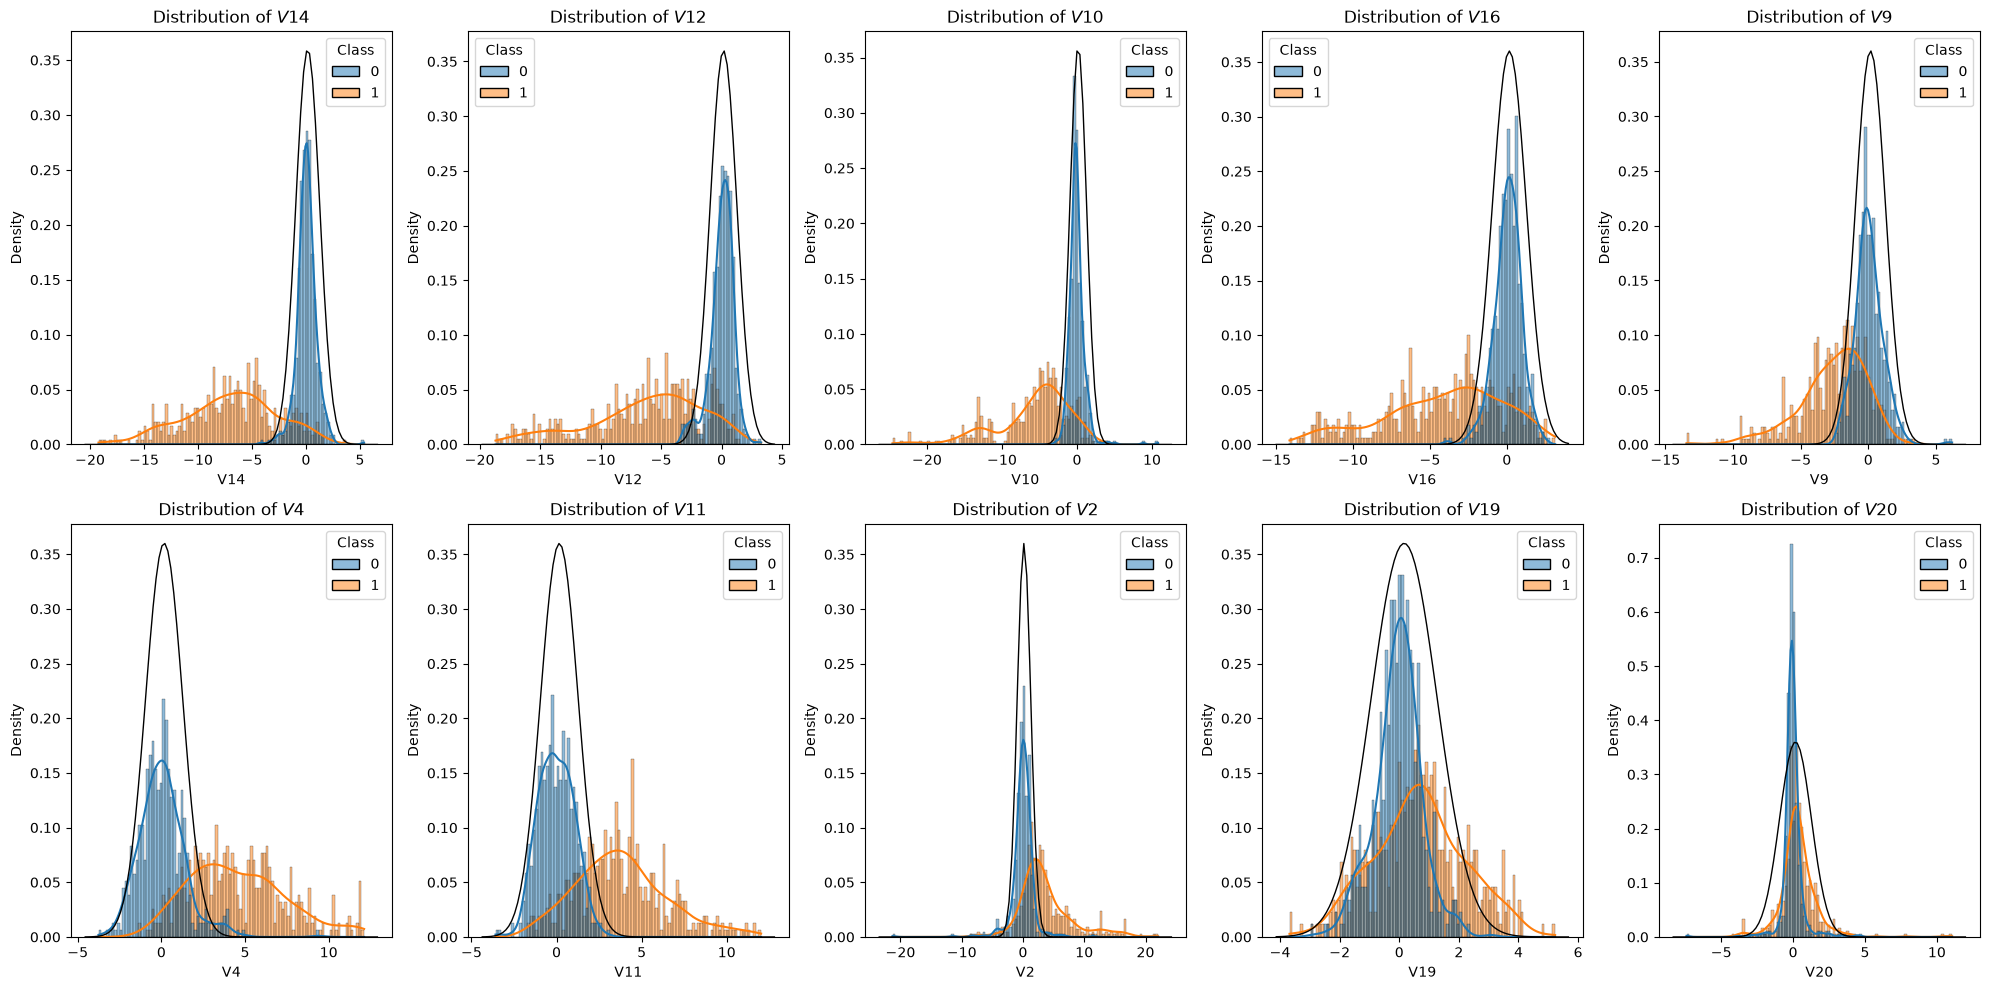

In [ ]:
from scipy.stats import norm

fig, axs = plt.subplots(2, 5, figsize=(20, 10))

N_bins = 100

for i, var in enumerate(main_neg_vars):

    sns.histplot(
        data=new_df,
        x=var,
        hue="Class",
        ax=axs[0, i],
        bins=N_bins,
        kde=True,
        stat='density',
        color='#e65454'
    )

    mu, std = norm.fit(data)
    xmin, xmax = axs[0, i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    axs[0, i].plot(x, p, 'k', linewidth=1)
    axs[0, i].set_title(fr"Distribution of ${var}$")


for i, var in enumerate(main_pos_vars):

    sns.histplot(
        data=new_df,
        x=var,
        hue="Class",
        ax=axs[1, i],
        bins=N_bins,
        kde=True,
        stat='density',
        color='#4965EC'
    )

    mu, std = norm.fit(data)
    xmin, xmax = axs[1, i].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mu, std)

    axs[1, i].plot(x, p, 'k', linewidth=1)
    axs[1, i].set_title(fr"Distribution of ${var}$")


plt.tight_layout()
plt.show()

## 2.7 Dimensionality Reduction using UMAP

In [ ]:
import umap

X,y = new_df.drop('Class',axis=1), new_df['Class']

reducer = umap.UMAP(random_state=42)
embedding = pd.DataFrame(reducer.fit_transform(X.values),columns=['UMAP1','UMAP2'])

c:\Users\gabriel.vernizi\Codes\ML\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
embedding['Label'] = y.values

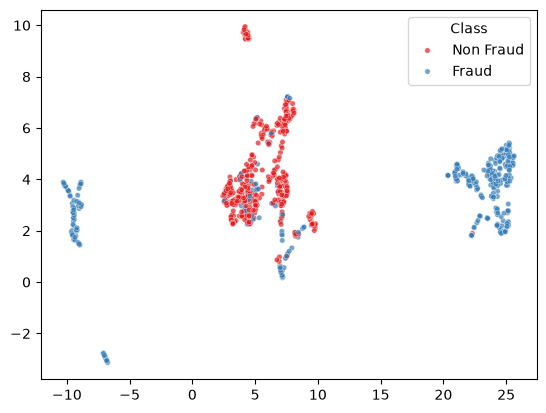

In [45]:
embedding['Class'] = embedding['Label'].map({
    0: 'Non Fraud',
    1: 'Fraud'
})

sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Class',
    data=embedding,
    palette='Set1',
    alpha=0.7,
    s=15
)

plt.xlabel('')
plt.ylabel('')
plt.legend(title='Class')
plt.savefig("Images/UMAP_Balanced")
plt.show()

c:\Users\gabriel.vernizi\Codes\ML\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


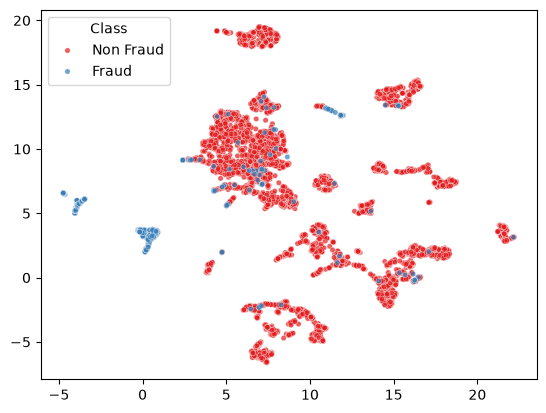

In [46]:
temp_df = pd.concat([df.sample(frac=1)[:10000], df_fraud],axis=0)
X2,y2 = temp_df.drop('Class',axis=1),temp_df['Class']

embedding2 = pd.DataFrame(umap.UMAP(random_state=42).fit_transform(X2.values),columns=['UMAP1','UMAP2'])

embedding2['Label'] = y2.values

embedding2['Class'] = embedding2['Label'].map({
    0: 'Non Fraud',
    1: 'Fraud'
})

sns.scatterplot(
    x='UMAP1',
    y='UMAP2',
    hue='Class',
    data=embedding2,
    palette='Set1',
    alpha=0.7,
    s=15
)

plt.xlabel('')
plt.ylabel('')
plt.legend(title='Class')
plt.savefig("Images/UMAP_Imbalanced_5000-Non-Frauds")
plt.show()

For almost every variable shown above, we can observe a noticeable separation between the two classes, which makes these features promising candidates for use in the subsequent modeling stage.

# 3. Pipeline

## 3.0 Functions 


### 3.0.1 Removing the outliers

For an set of variables, we iterate over then, removing the outliers that exceds the range of $( Quartile_{25} - IQR * L, Quartile_{75} + IQR * L)$, where $L$ is a value that our hearts tells us its enough (threshold).

In [ ]:
from numpy import quantile

def remove_outliers(df, variable, threshold=1.5):
    q25,q75 = np.quantile(df[variable],0.25), np.quantile(df[variable],0.75)
    IQR = q75 - q25

    lowerBound,upperBound = q25 - IQR * threshold, q75 + IQR * threshold
    mask = (df[variable] < lowerBound) | (df[variable] > upperBound)
    remove_index = df[mask].index
    return remove_index


## 3.1 Separation of the data

In [ ]:
from sklearn.model_selection import train_test_split

X = new_df.drop("Class",axis=1)
y = new_df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import classification_report, confusion_matrix

In [64]:
df_train = pd.concat([X_train,y_train],axis=1)

variables = ['V14','V12','V11']

for var in variables:
    df_train.drop(index=remove_outliers(df_train,var),inplace=True)

modelos = {
    'SVM': SVC(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier()
}

for name, classifier in modelos.items():
    print(f"--- Model: {name} ---")
    print(classifier)
    
    pipeline = Pipeline(steps=[
        ('classifier', classifier)
    ])
    
    pipeline.fit(X_train, y_train)
    
    y_pred = pipeline.predict(X_test)
    
    print("Confusion Matrix:\n")
    print(confusion_matrix(y_test, y_pred))
    print("\n")
    print(classification_report(y_test, y_pred))
    print("="*40 + "\n")

--- Model: SVM ---
SVC(random_state=42)
Confusion Matrix:

[[163   3]
 [ 22 137]]


              precision    recall  f1-score   support

           0       0.88      0.98      0.93       166
           1       0.98      0.86      0.92       159

    accuracy                           0.92       325
   macro avg       0.93      0.92      0.92       325
weighted avg       0.93      0.92      0.92       325


--- Model: Random Forest ---
RandomForestClassifier(random_state=42)
Confusion Matrix:

[[163   3]
 [ 19 140]]


              precision    recall  f1-score   support

           0       0.90      0.98      0.94       166
           1       0.98      0.88      0.93       159

    accuracy                           0.93       325
   macro avg       0.94      0.93      0.93       325
weighted avg       0.94      0.93      0.93       325


--- Model: KNN ---
KNeighborsClassifier()
Confusion Matrix:

[[161   5]
 [ 23 136]]


              precision    recall  f1-score   support

      